# **📕 Import Library**

In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import joblib
warnings.filterwarnings('ignore')

# **📊 Load Dataset**

In [2]:
df1 = pd.read_csv('/kaggle/input/datasets/sparkyxt/calories-burning-dataset/calories.csv')
df2 = pd.read_csv('/kaggle/input/datasets/sparkyxt/calories-burning-dataset/exercise.csv')

#merge dataset
df = df2.merge(df1, on = 'User_ID', how = 'left')

df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


# **⌛ EDA & Preprocessing**

## **Statistic Descriptive** 

In [3]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


## **Data Summary**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


## **Check Data Duplication** 

In [5]:
df.duplicated().sum()

np.int64(0)

## **Check Missing Values** 

In [6]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

## **Data Visualization** 

<Axes: xlabel='Gender', ylabel='count'>

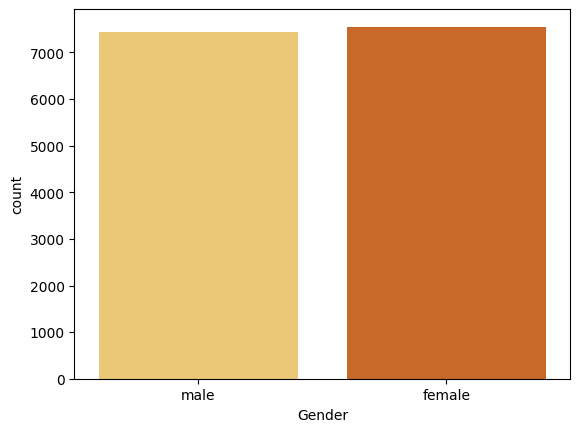

In [7]:
sns.countplot(data=df, x='Gender', palette='YlOrBr')

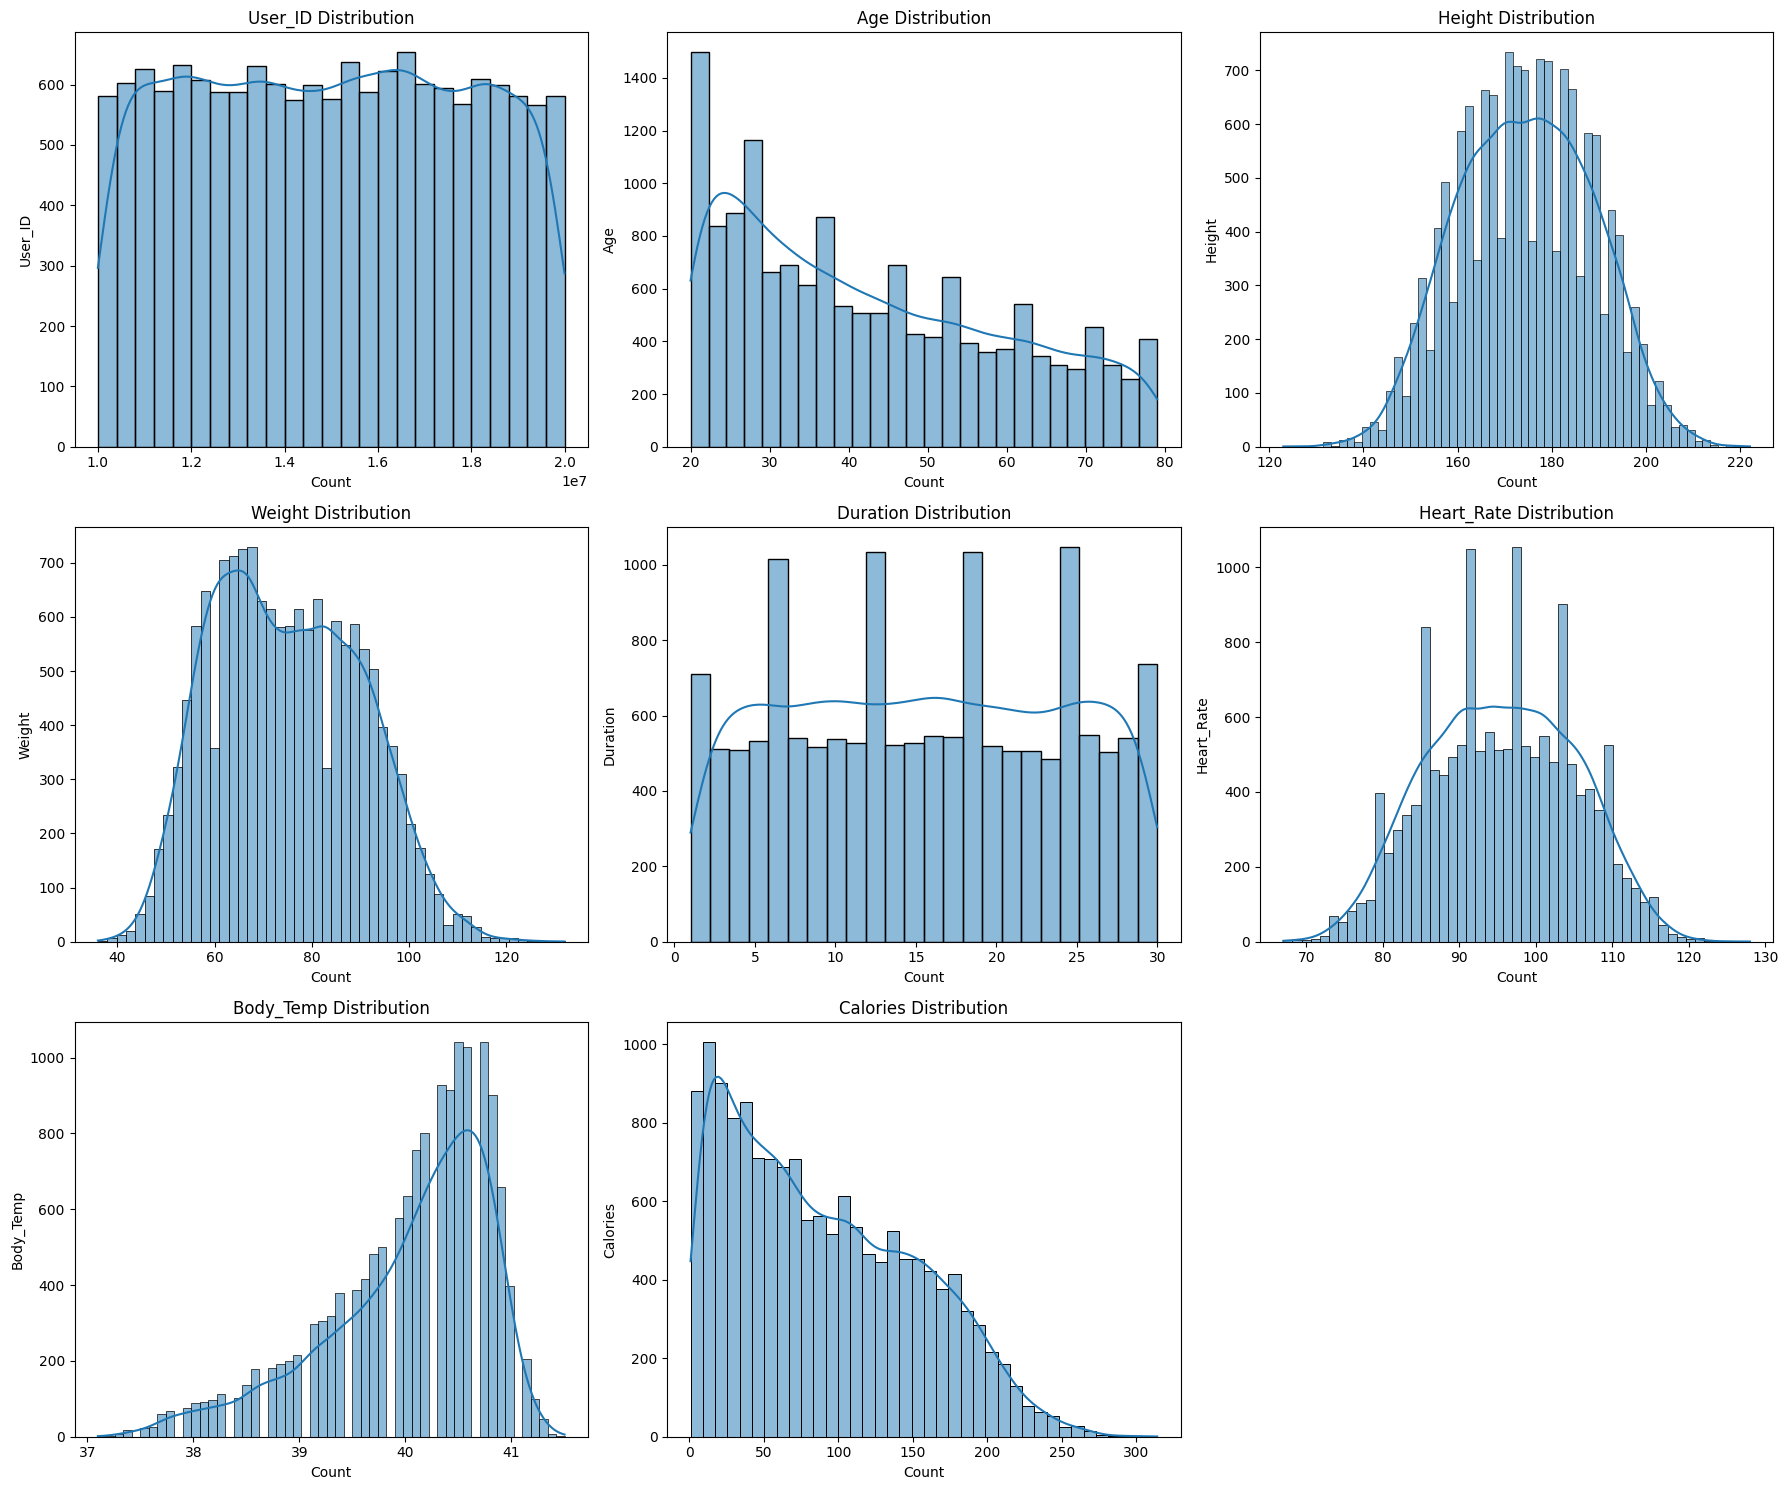

In [8]:
numeric = df.select_dtypes(include='number').columns.tolist()
n_cols = 3
n_rows = math.ceil(len(numeric) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(numeric):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_ylabel(col)
    axes[i].set_xlabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
plt.tight_layout()
plt.show()

<Axes: >

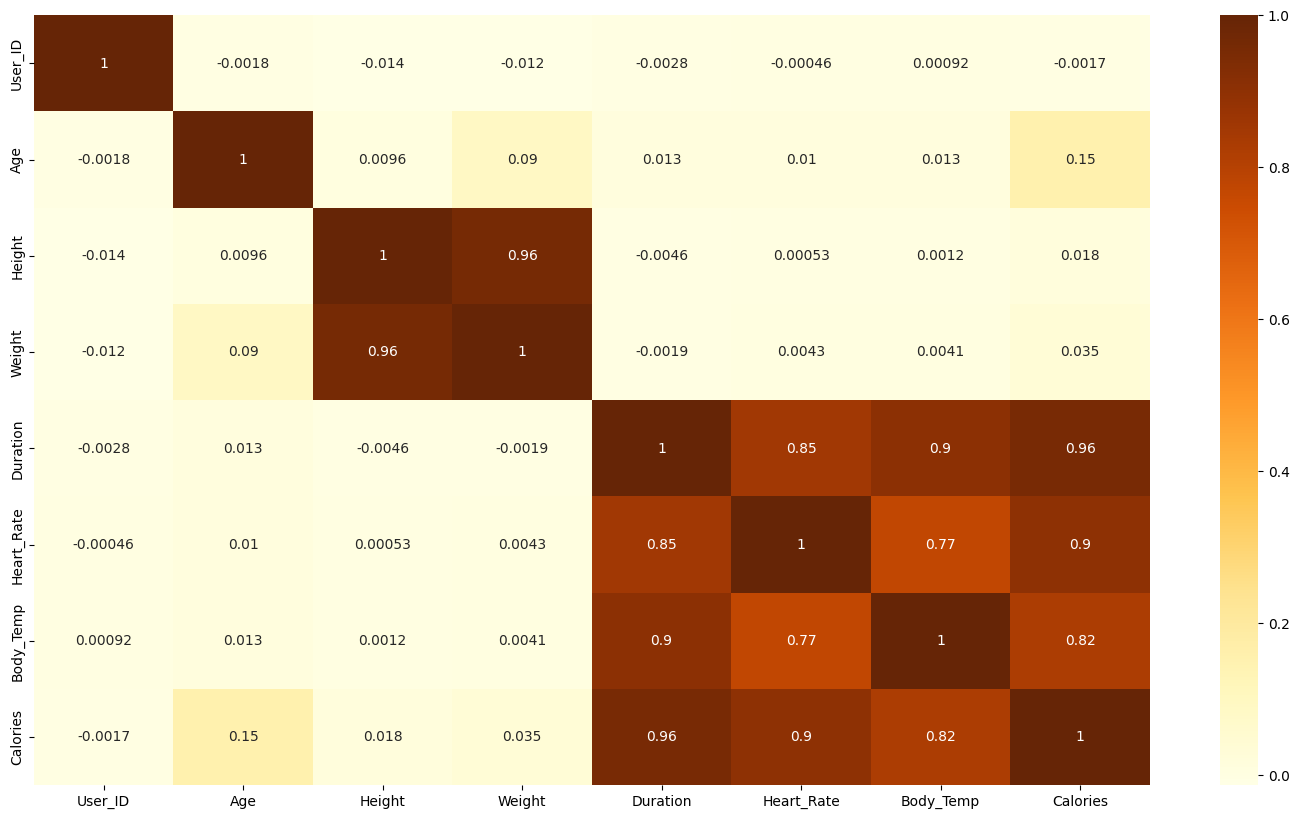

In [9]:
correlation = df[numeric].corr()

plt.figure(figsize=(18,10))
sns.heatmap(correlation, annot=True, cmap='YlOrBr')

# **🎯 Target Mapping**  

In [10]:
df['Gender'] = df['Gender'].map({'male': 1, 'female':0})
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,0,27,154.0,58.0,10.0,81.0,39.8,35.0


# **✂️ Data Splitting** 

In [11]:
X = df.drop(columns=['Calories', 'User_ID'], axis=1)
y = df['Calories']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

print('Shape of X Train: ', X_train.shape)
print('Shape of X Test: ', X_test.shape)
print('Shape of y Train: ', y_train.shape)
print('Shape of y Test: ', y_test.shape)

Shape of X Train:  (12000, 7)
Shape of X Test:  (3000, 7)
Shape of y Train:  (12000,)
Shape of y Test:  (3000,)


# **🔎 Modelling and Evaluation**

In [13]:
def predict(ml_model):
    model = ml_model.fit(X_train, y_train)
    print('Score : {}'.format(model.score(X_train, y_train)))
    y_prediction = model.predict(X_test)
    print('predictions are: \n {}'.format(y_prediction))
    print('\n')
    
    r2_score = metrics.r2_score(y_test, y_prediction)
    print('r2_score: {}'.format(r2_score))
    
    print('MAE:',metrics.mean_absolute_error(y_test,y_prediction))
    print('MSE:',metrics.mean_squared_error(y_test,y_prediction))
    print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test,y_prediction)))
    
    sns.histplot(y_test-y_prediction)

Score : 0.9995380557081355
predictions are: 
 [197.06581   70.867226 196.99498  ...  29.043041 104.09284   14.61472 ]


r2_score: 0.9986863132331905
MAE: 1.5521575984954834
MSE: 5.2744122853837005
RMSE: 2.2966088664340956


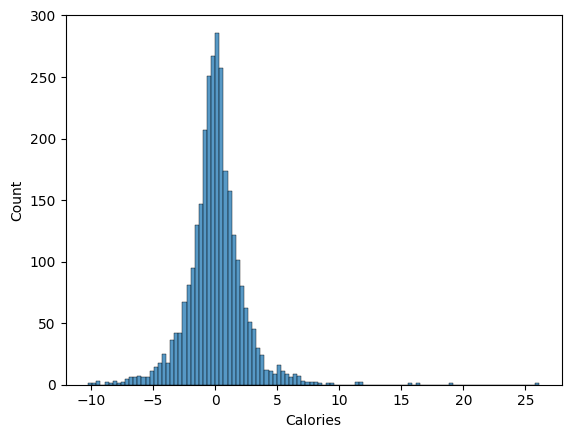

In [14]:
regression = predict(XGBRegressor())
regression

Score : 0.9999630761119152
predictions are: 
 [198.33198391  72.13134263 194.87141007 ...  28.27006815 108.10630668
  14.65318516]


r2_score: 0.9999065115566808
MAE: 0.3090477233795114
MSE: 0.37535324739716636
RMSE: 0.6126607930961196


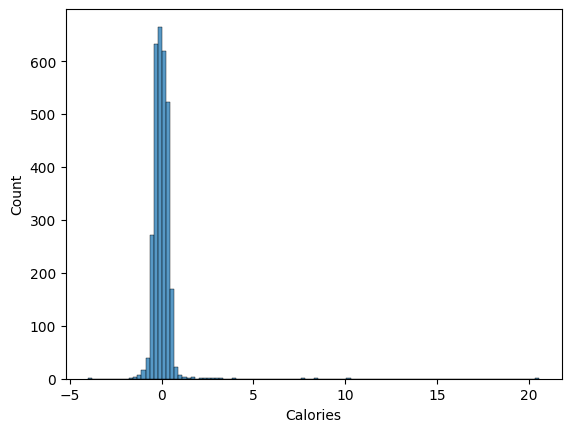

In [15]:
predict(Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1))
]))

In [16]:
# fit ulang pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1))
])

In [17]:
pipeline.fit(X_train, y_train)

# simpan
joblib.dump(pipeline, 'svr_model.pkl')
print("Model saved!")

Model saved!


In [18]:
# verifikasi
model_test = joblib.load('svr_model.pkl')
print(model_test.predict(X_test[:3]))

[198.33198391  72.13134263 194.87141007]


Score : 0.999924978253828
predictions are: 
 [198.63121099  72.40514524 194.13710314 ...  28.30971822 108.34778229
  14.25162941]


r2_score: 0.9997857284776762
MAE: 0.522594142467125
MSE: 0.860293624253494
RMSE: 0.9275201476267209


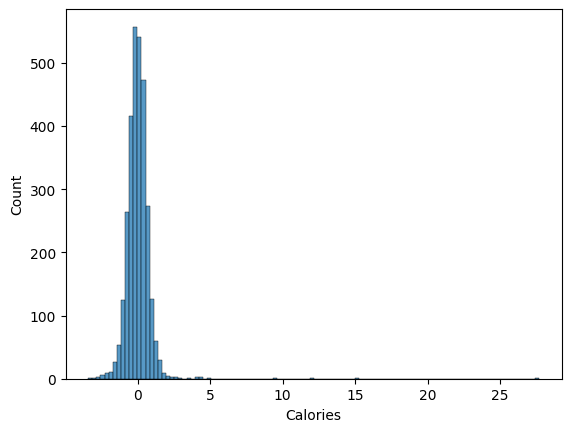

In [19]:
predict(CatBoostRegressor(verbose=False))